# Trabalho DCGAN — Geração de rostos (CelebA)
DCGAN com curadoria de dados, spectral norm, TTUR e treino em precisão mista (AMP). Nativo do Kaggle.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torchvision.utils as vutils
import os
import kagglehub
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Parametros
latent_dim       = 100
img_channels     = 3
img_size         = 64
batch_size       = 512       # batch grande aproveita melhor a GPU
epochs           = 150
learning_rate_G  = 0.0002    # TTUR: G com LR maior
learning_rate_D  = 0.0001    # D com LR menor, para estabilidade
beta1, beta2     = 0.5, 0.999
max_samples      = None
num_workers      = 4
save_interval    = 10        # salva checkpoint a cada 10 epochs
sample_interval  = 5         # salva amostras a cada 5 epochs
checkpoint_dir   = "/kaggle/working/checkpoints"
sample_dir       = "/kaggle/working/samples"
use_amp          = True      # precisao mista, acelera o treino

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(sample_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando em: {device}")

if use_amp and not torch.cuda.is_available():
    use_amp = False

Treinando em: cuda


In [3]:
# Dataset e curadoria
print("Baixando / localizando o CelebA...")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

class CelebACuradoDataset(Dataset):
    # Mantem apenas rostos frontais, sem oculos/chapeu/barba.
    # Filtro de atributos: usa list_attr_celeba.csv
    # Filtro geometrico: usa os landmarks (olhos e nariz) para medir simetria -> rosto frontal

    def __init__(self, root_dir, transform=None, max_samples=None):
        self.transform = transform
        self.img_dir = os.path.join(root_dir, "img_align_celeba", "img_align_celeba")
        if not os.path.exists(self.img_dir):
            self.img_dir = os.path.join(root_dir, "img_align_celeba")

        # carrega atributos + landmarks e junta por image_id
        df_attr      = pd.read_csv(os.path.join(root_dir, "list_attr_celeba.csv"))
        df_landmarks = pd.read_csv(os.path.join(root_dir, "list_landmarks_align_celeba.csv"))
        df = pd.merge(df_attr, df_landmarks, on="image_id")
        total_orig = len(df)

        # 1) atributos: fora do padrao = oculos, chapeu ou barba
        filtro_attr = (
            (df["Eyeglasses"]  == -1) &
            (df["Wearing_Hat"] == -1) &
            (df["No_Beard"]    ==  1)
        )

        # 2) geometria: simetria do rosto (distancia olho-nariz dos dois lados)
        dist_esq = (df["nose_x"]     - df["lefteye_x"]).astype(float)
        dist_dir = (df["righteye_x"] - df["nose_x"]).astype(float)
        positivas = (dist_esq > 0) & (dist_dir > 0)
        simetria  = dist_esq / dist_dir.clip(lower=1e-6)
        filtro_frontal = (simetria > 0.75) & (simetria < 1.333) & positivas

        df_filtrado = df[filtro_attr & filtro_frontal].copy()
        total_filt  = len(df_filtrado)

        print("\n--- Estatisticas da curadoria ----------------------")
        print(f"  Imagens originais       : {total_orig:>9,}")
        print(f"  Apos os filtros         : {total_filt:>9,}")

        # subconjunto aleatorio (sem vies de ordem) se pedirem max_samples
        if max_samples and max_samples < total_filt:
            df_filtrado = df_filtrado.sample(n=max_samples, random_state=42)
            print(f"  Subconjunto usado       : {len(df_filtrado):>9,}")
        print("----------------------------------------------------\n")

        self.image_files = df_filtrado["image_id"].values

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0


transform = transforms.Compose([
    transforms.CenterCrop(160),                       # centraliza o rosto (imagem "concentrica")
    transforms.Resize((img_size, img_size),
                      interpolation=transforms.InterpolationMode.LANCZOS),  # downsample preservando detalhe
    transforms.RandomHorizontalFlip(p=0.5),           # mais variedade de pose, de graca
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [-1,1], casa com a Tanh
])

dataset = CelebACuradoDataset(root_dir=dataset_path, transform=transform, max_samples=max_samples)
dataloader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=torch.cuda.is_available(), drop_last=True,
    persistent_workers=(num_workers > 0),
    prefetch_factor=(2 if num_workers > 0 else None),
)
print(f"DataLoader pronto: {len(dataset):,} imagens | {len(dataloader)} batches/epoch")

Baixando / localizando o CelebA...

--- Estatisticas da curadoria ----------------------
  Imagens originais       :   202,599
  Apos os filtros         :    63,183
----------------------------------------------------

DataLoader pronto: 63,183 imagens | 123 batches/epoch


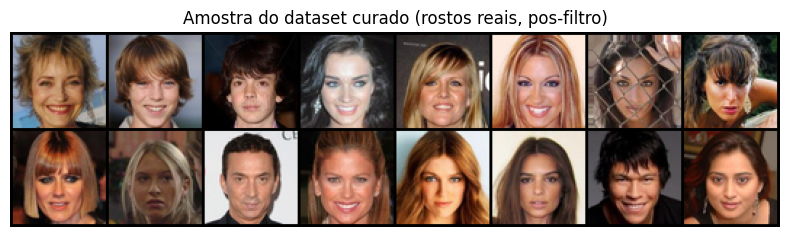

In [4]:
# Visualizacao da curadoria
def mostra_batch_real(loader):
    batch = next(iter(loader))
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Amostra do dataset curado (rostos reais, pos-filtro)")
    plt.imshow(np.transpose(
        vutils.make_grid(batch[0][:16], padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.tight_layout()
    plt.savefig(os.path.join(sample_dir, "real_samples.png"), dpi=150)
    plt.show()

mostra_batch_real(dataloader)

In [5]:
# Modelos e inicializacao
def weights_init(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

ngf, ndf = 64, 64

class Generator(nn.Module):
    # vetor latente z -> imagem RGB 64x64 ; BatchNorm + ReLU nas ocultas, Tanh na saida
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),  # -> 4x4
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),     # -> 8x8
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),     # -> 16x16
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),         # -> 32x32
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, img_channels, 4, 2, 1, bias=False),    # -> 64x64
            nn.Tanh(),
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    # imagem RGB 64x64 -> logit escalar ; spectral norm + LeakyReLU, sem Sigmoid (BCEWithLogits)
    def __init__(self):
        super().__init__()
        sn = nn.utils.spectral_norm
        self.main = nn.Sequential(
            sn(nn.Conv2d(img_channels, ndf, 4, 2, 1, bias=False)),         # -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),              # -> 16x16
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),          # -> 8x8
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),          # -> 4x4
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)),                # -> 1x1 logit
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

generator     = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

print(f"Parametros Generator    : {sum(p.numel() for p in generator.parameters()):>12,}")
print(f"Parametros Discriminator: {sum(p.numel() for p in discriminator.parameters()):>12,}")

criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(generator.parameters(),     lr=learning_rate_G, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate_D, betas=(beta1, beta2))

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

Parametros Generator    :    3,576,704
Parametros Discriminator:    2,765,568


/tmp/ipykernel_57/4223954300.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [6]:
# Treinamento
print("Iniciando o treino...")
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

G_losses, D_losses = [], []
REAL_LABEL = 0.9   # label smoothing: D nao precisa ser 100% certo no real
FAKE_LABEL = 0.0

for epoch in range(1, epochs + 1):
    generator.train(); discriminator.train()
    epoch_G, epoch_D = [], []

    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device, non_blocking=True)
        b_size    = real_imgs.size(0)
        real_labels = torch.full((b_size, 1), REAL_LABEL, device=device)
        fake_labels = torch.zeros((b_size, 1), device=device)

        # ---- Discriminador ----
        discriminator.zero_grad()
        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss_D_real = criterion(discriminator(real_imgs), real_labels)
            noise     = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            loss_D_fake = criterion(discriminator(fake_imgs.detach()), fake_labels)
            loss_D = loss_D_real + loss_D_fake
        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)

        # ---- Gerador ----
        generator.zero_grad()
        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss_G = criterion(discriminator(fake_imgs), torch.ones((b_size, 1), device=device))
        scaler.scale(loss_G).backward()
        scaler.unscale_(optimizer_G)
        nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)  # estabiliza o G
        scaler.step(optimizer_G)
        scaler.update()

        G_losses.append(loss_G.item()); D_losses.append(loss_D.item())
        epoch_G.append(loss_G.item());  epoch_D.append(loss_D.item())

        if i % 50 == 0:
            print(f"  [{epoch:3d}/{epochs}][{i:4d}/{len(dataloader)}]  "
                  f"Loss_D: {loss_D.item():.4f}   Loss_G: {loss_G.item():.4f}")

    print(f"\n{'-'*60}")
    print(f"  Epoch {epoch}/{epochs} | avg Loss_D: {np.mean(epoch_D):.4f}  avg Loss_G: {np.mean(epoch_G):.4f}")
    print(f"{'-'*60}\n")

    # amostras periodicas (para acompanhar / montar GIF)
    if epoch % sample_interval == 0 or epoch == epochs:
        generator.eval()
        with torch.no_grad():
            fake_grid = generator(fixed_noise).detach().cpu()
        out_path = os.path.join(sample_dir, f"samples_epoch_{epoch:04d}.png")
        vutils.save_image(fake_grid, out_path, normalize=True, nrow=4)
        print(f"  Amostras salvas -> {out_path}")
        generator.train()

    # checkpoint periodico
    if epoch % save_interval == 0 or epoch == epochs:
        ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch:04d}.pth")
        torch.save({
            "epoch": epoch,
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "optimizer_G": optimizer_G.state_dict(),
            "optimizer_D": optimizer_D.state_dict(),
            "scaler": scaler.state_dict(),
            "G_losses": G_losses, "D_losses": D_losses,
        }, ckpt_path)
        print(f"  Checkpoint salvo -> {ckpt_path}")

print("\nTreino concluido.")

Iniciando o treino...
  [  1/150][   0/123]  Loss_D: 1.6213   Loss_G: 2.4009
  [  1/150][  50/123]  Loss_D: 0.4129   Loss_G: 7.1054
  [  1/150][ 100/123]  Loss_D: 0.7218   Loss_G: 7.4857

------------------------------------------------------------
  Epoch 1/150 | avg Loss_D: 0.6999  avg Loss_G: 7.1295
------------------------------------------------------------

  [  2/150][   0/123]  Loss_D: 1.0410   Loss_G: 2.0820
  [  2/150][  50/123]  Loss_D: 1.4275   Loss_G: 3.3464
  [  2/150][ 100/123]  Loss_D: 1.2480   Loss_G: 2.3151

------------------------------------------------------------
  Epoch 2/150 | avg Loss_D: 1.2727  avg Loss_G: 3.1093
------------------------------------------------------------

  [  3/150][   0/123]  Loss_D: 0.9989   Loss_G: 2.3134
  [  3/150][  50/123]  Loss_D: 1.0046   Loss_G: 2.9174
  [  3/150][ 100/123]  Loss_D: 1.1560   Loss_G: 2.4085

------------------------------------------------------------
  Epoch 3/150 | avg Loss_D: 1.2344  avg Loss_G: 2.8805
--------

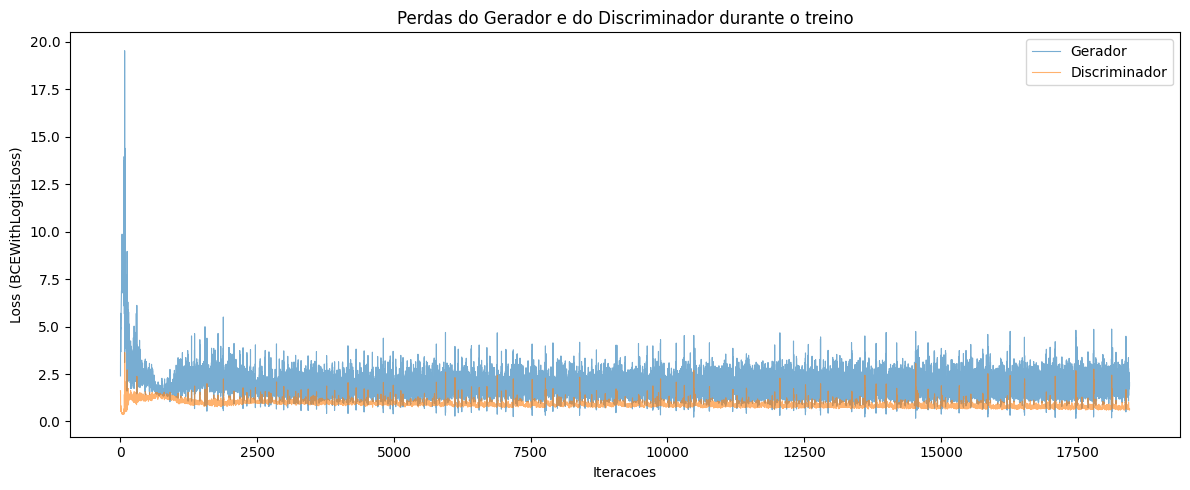

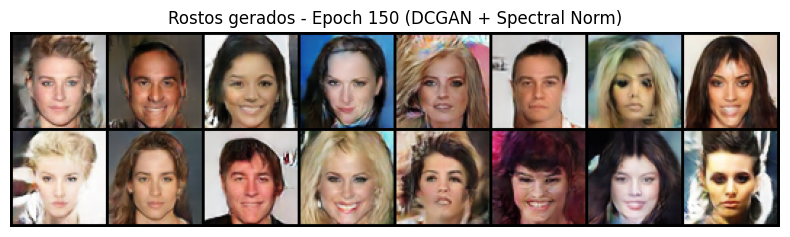

Saidas salvas em: /kaggle/working/samples/


In [7]:
# Resultados finais
plt.figure(figsize=(12, 5))
plt.title("Perdas do Gerador e do Discriminador durante o treino")
plt.plot(G_losses, label="Gerador",       alpha=0.6, linewidth=0.8)
plt.plot(D_losses, label="Discriminador", alpha=0.6, linewidth=0.8)
plt.xlabel("Iteracoes"); plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(sample_dir, "training_losses.png"), dpi=150)
plt.show()

generator.eval()
with torch.no_grad():
    fake_samples = generator(fixed_noise).detach().cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title(f"Rostos gerados - Epoch {epochs} (DCGAN + Spectral Norm)")
plt.imshow(np.transpose(vutils.make_grid(fake_samples, padding=2, normalize=True), (1, 2, 0)))
plt.tight_layout()
plt.savefig(os.path.join(sample_dir, "final_generated_faces.png"), dpi=150)
plt.show()

print(f"Saidas salvas em: {sample_dir}/")

## Comparação: com curadoria × sem curadoria
Experimento controlado: dois DCGANs **idênticos** (mesma arquitetura, mesma inicialização, mesmas
épocas e o **mesmo número de imagens**) — a única diferença é o conjunto de treino. Um treina nas
imagens **curadas** (frontais, sem óculos/chapéu/barba); o outro num conjunto **aleatório sem filtro**.
Isso isola o efeito da curadoria. Use poucas épocas: o objetivo aqui é comparar, não bater recorde.

In [8]:
# Comparacao: parametros e os dois datasets (mesmo numero de imagens)
compare_epochs  = 20        # epocas para CADA modelo (curto, so para comparar)
compare_samples = 30000     # MESMO numero de imagens nos dois (tira o tamanho como variavel)
compare_seed    = 123

# dataset SEM curadoria: imagens aleatorias, sem nenhum filtro
class CelebARawDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=None, seed=42):
        self.transform = transform
        img_dir = os.path.join(root_dir, "img_align_celeba", "img_align_celeba")
        if not os.path.exists(img_dir):
            img_dir = os.path.join(root_dir, "img_align_celeba")
        self.img_dir = img_dir
        files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        rng = np.random.default_rng(seed)
        rng.shuffle(files)
        if max_samples:
            files = files[:max_samples]
        self.image_files = files
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.image_files[idx])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

ds_curado = CelebACuradoDataset(dataset_path, transform=transform, max_samples=compare_samples)
ds_raw    = CelebARawDataset(dataset_path,   transform=transform, max_samples=compare_samples)
print(f"com curadoria: {len(ds_curado):,} imagens | sem curadoria: {len(ds_raw):,} imagens")


--- Estatisticas da curadoria ----------------------
  Imagens originais       :   202,599
  Apos os filtros         :    63,183
  Subconjunto usado       :    30,000
----------------------------------------------------

com curadoria: 30,000 imagens | sem curadoria: 30,000 imagens


In [9]:
# Funcao que treina um DCGAN do zero (mesma receita do treino principal) e devolve o gerador
def treina_rapido(ds, epochs, seed):
    torch.manual_seed(seed)   # mesma inicializacao para os dois -> isola o efeito dos dados
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers,
                        pin_memory=torch.cuda.is_available(), drop_last=True)
    G = Generator().to(device); D = Discriminator().to(device)
    G.apply(weights_init); D.apply(weights_init)
    optG = optim.Adam(G.parameters(),     lr=learning_rate_G, betas=(beta1, beta2))
    optD = optim.Adam(D.parameters(),     lr=learning_rate_D, betas=(beta1, beta2))
    sc = torch.cuda.amp.GradScaler(enabled=use_amp)
    for ep in range(1, epochs + 1):
        for imgs, _ in loader:
            real = imgs.to(device, non_blocking=True); b = real.size(0)
            rl = torch.full((b, 1), 0.9, device=device); fl = torch.zeros((b, 1), device=device)
            D.zero_grad()
            with torch.autocast(device_type=device.type, enabled=use_amp):
                lD = criterion(D(real), rl)
                noise = torch.randn(b, latent_dim, 1, 1, device=device); fake = G(noise)
                lD = lD + criterion(D(fake.detach()), fl)
            sc.scale(lD).backward(); sc.step(optD)
            G.zero_grad()
            with torch.autocast(device_type=device.type, enabled=use_amp):
                lG = criterion(D(fake), torch.ones((b, 1), device=device))
            sc.scale(lG).backward(); sc.unscale_(optG)
            nn.utils.clip_grad_norm_(G.parameters(), 1.0); sc.step(optG); sc.update()
        print(f"  epoch {ep:2d}/{epochs}  Loss_D {lD.item():.3f}  Loss_G {lG.item():.3f}")
    return G

# mesmo ruido fixo para os dois -> grids diretamente comparaveis (mesmos pontos latentes)
cmp_noise = torch.randn(16, latent_dim, 1, 1, device=device)

print("=== Treinando SEM curadoria ===")
G_raw = treina_rapido(ds_raw, compare_epochs, compare_seed)
print("=== Treinando COM curadoria ===")
G_cur = treina_rapido(ds_curado, compare_epochs, compare_seed)

=== Treinando SEM curadoria ===


/tmp/ipykernel_57/3646724482.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sc = torch.cuda.amp.GradScaler(enabled=use_amp)


  epoch  1/20  Loss_D 0.478  Loss_G 7.466
  epoch  2/20  Loss_D 1.397  Loss_G 4.676
  epoch  3/20  Loss_D 0.877  Loss_G 3.765
  epoch  4/20  Loss_D 1.041  Loss_G 2.800
  epoch  5/20  Loss_D 1.320  Loss_G 3.645
  epoch  6/20  Loss_D 1.108  Loss_G 2.263
  epoch  7/20  Loss_D 1.205  Loss_G 3.211
  epoch  8/20  Loss_D 1.228  Loss_G 2.794
  epoch  9/20  Loss_D 1.205  Loss_G 2.541
  epoch 10/20  Loss_D 1.264  Loss_G 2.499
  epoch 11/20  Loss_D 1.231  Loss_G 2.117
  epoch 12/20  Loss_D 1.093  Loss_G 1.902
  epoch 13/20  Loss_D 1.032  Loss_G 2.208
  epoch 14/20  Loss_D 1.041  Loss_G 2.368
  epoch 15/20  Loss_D 0.985  Loss_G 2.372
  epoch 16/20  Loss_D 1.149  Loss_G 1.584
  epoch 17/20  Loss_D 0.973  Loss_G 2.655
  epoch 18/20  Loss_D 0.878  Loss_G 2.461
  epoch 19/20  Loss_D 0.906  Loss_G 2.703
  epoch 20/20  Loss_D 0.683  Loss_G 2.824
=== Treinando COM curadoria ===
  epoch  1/20  Loss_D 0.415  Loss_G 7.196
  epoch  2/20  Loss_D 0.796  Loss_G 4.405
  epoch  3/20  Loss_D 1.710  Loss_G 3.838
  

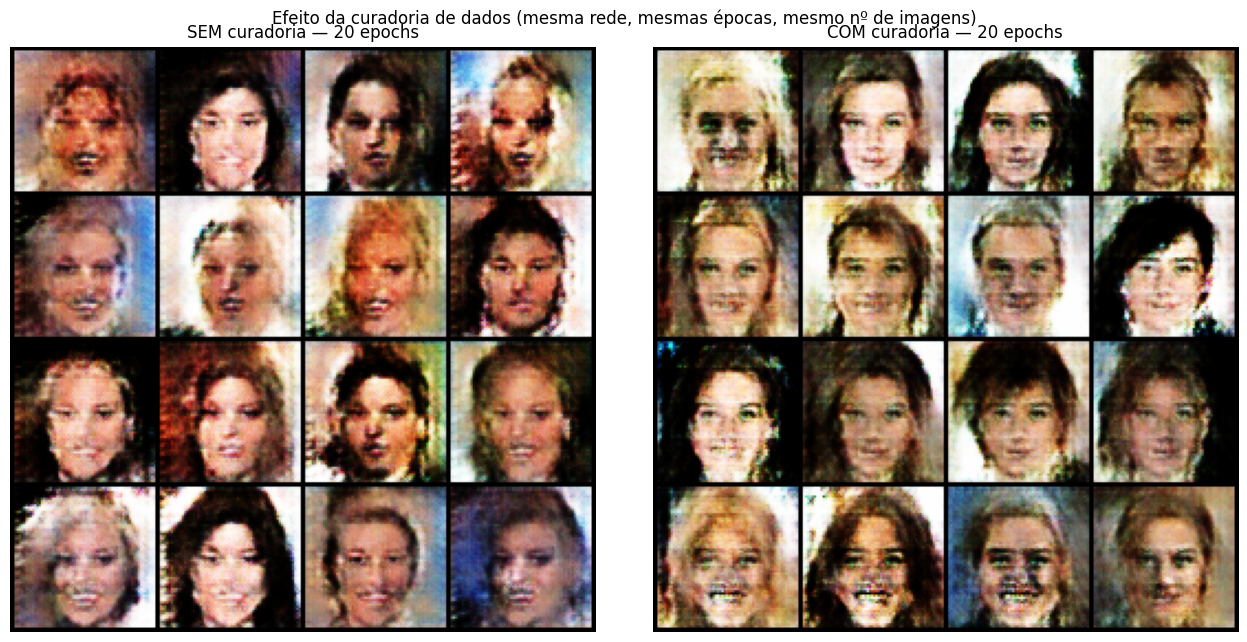

Comparação salva em: /kaggle/working/samples/comparacao_curadoria.png


In [10]:
# Comparacao lado a lado
def grid_de(G):
    G.eval()
    with torch.no_grad():
        f = G(cmp_noise).detach().cpu()
    return np.transpose(vutils.make_grid(f, padding=2, normalize=True, nrow=4).numpy(), (1, 2, 0))

fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
axs[0].imshow(grid_de(G_raw)); axs[0].axis("off")
axs[0].set_title(f"SEM curadoria — {compare_epochs} epochs")
axs[1].imshow(grid_de(G_cur)); axs[1].axis("off")
axs[1].set_title(f"COM curadoria — {compare_epochs} epochs")
plt.suptitle("Efeito da curadoria de dados (mesma rede, mesmas épocas, mesmo nº de imagens)")
plt.tight_layout()
plt.savefig(os.path.join(sample_dir, "comparacao_curadoria.png"), dpi=150)
plt.show()
print("Comparação salva em:", os.path.join(sample_dir, "comparacao_curadoria.png"))